Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Fashion Classification Assessment**

---

### **Import Libraries**

In [8]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


Tensorflow: 2.17.0
 Pandas: 2.2.3
 numpy: 1.26.4
 sklearn: 1.5.2



### **Prep Dataset**

In [9]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [10]:
train_data.shape, train_labels.shape

((60000, 28, 28), (60000,))

In [11]:
train_data[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [12]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

len(class_names)

10

In [13]:
train_data_normalized = train_data / 255.0
test_data_normalized = test_data / 255.0

train_data_normalized.min(), train_data_normalized.max()

(0.0, 1.0)

### **Find the Ideal Learning Rate**

#### **Ideal Learning Rate for Raw Data**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/30))

history = model.fit(train_data, train_labels, 
                    epochs=150,
                    batch_size=128,
                    callbacks=[lr_callback])  



Epoch 1/150


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 9/59 [===>..........................] - ETA: 0s - loss: 126.0557 - accuracy: 0.0998  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


59/59 [==============================] - 2s 8ms/step - loss: 97.7643 - accuracy: 0.1142 - lr: 1.0000e-05
Epoch 2/150
59/59 [==============================] - 0s 8ms/step - loss: 58.6719 - accuracy: 0.1983 - lr: 1.0798e-05
Epoch 3/150
59/59 [==============================] - 0s 8ms/step - loss: 37.0106 - accuracy: 0.3198 - lr: 1.1659e-05
Epoch 4/150
59/59 [==============================] - 0s 7ms/step - loss: 25.7374 - accuracy: 0.4119 - lr: 1.2589e-05
Epoch 5/150
59/59 [==============================] - 0s 7ms/step - loss: 20.1953 - accuracy: 0.4825 - lr: 1.3594e-05
Epoch 6/150
59/59 [==============================] - 0s 7ms/step - loss: 16.8798 - accuracy: 0.5306 - lr: 1.4678e-05
Epoch 7/150
59/59 [==============================] - 0s 7ms/step - loss: 14.5534 - accuracy: 0.5649 - lr: 1.5849e-05
Epoch 8/150
59/59 [==============================] - 0s 7ms/step - loss: 12.7968 - accuracy: 0.5903 - lr: 1.7113e-05
Epoch 9/150
59/59 [==============================] - 0s 6ms/step - loss: 11.

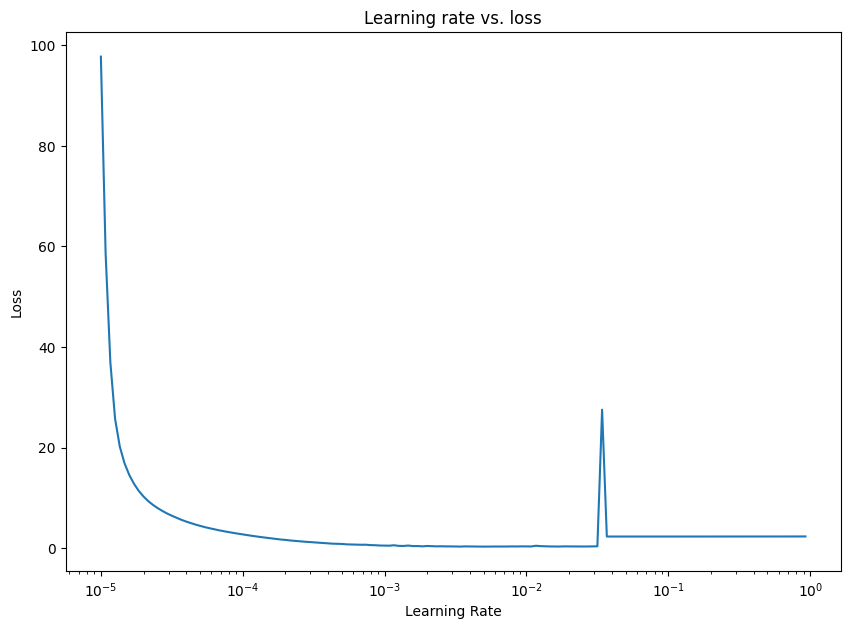

In [15]:
lrs = 1e-5 * (10 ** (np.arange(150)/30))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 6e-4``` is the safest option.

#### **Ideal Learning Rate for Normalized Data**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/30))

history = model.fit(train_data_normalized, train_labels, 
                    epochs=150,
                    batch_size=128,
                    callbacks=[lr_callback])  



Epoch 1/150


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


14/59 [======>.......................] - ETA: 0s - loss: 2.3847 - accuracy: 0.1637

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


59/59 [==============================] - 2s 8ms/step - loss: 2.3233 - accuracy: 0.1793 - lr: 1.0000e-05
Epoch 2/150
59/59 [==============================] - 1s 9ms/step - loss: 2.1782 - accuracy: 0.2108 - lr: 1.0798e-05
Epoch 3/150
59/59 [==============================] - 0s 8ms/step - loss: 2.0424 - accuracy: 0.3064 - lr: 1.1659e-05
Epoch 4/150
59/59 [==============================] - 0s 8ms/step - loss: 1.9081 - accuracy: 0.4147 - lr: 1.2589e-05
Epoch 5/150
59/59 [==============================] - 0s 7ms/step - loss: 1.7672 - accuracy: 0.5088 - lr: 1.3594e-05
Epoch 6/150
59/59 [==============================] - 0s 7ms/step - loss: 1.6098 - accuracy: 0.5714 - lr: 1.4678e-05
Epoch 7/150
59/59 [==============================] - 0s 8ms/step - loss: 1.4454 - accuracy: 0.6156 - lr: 1.5849e-05
Epoch 8/150
59/59 [==============================] - 0s 8ms/step - loss: 1.2951 - accuracy: 0.6519 - lr: 1.7113e-05
Epoch 9/150
59/59 [==============================] - 0s 8ms/step - loss: 1.1738 - ac

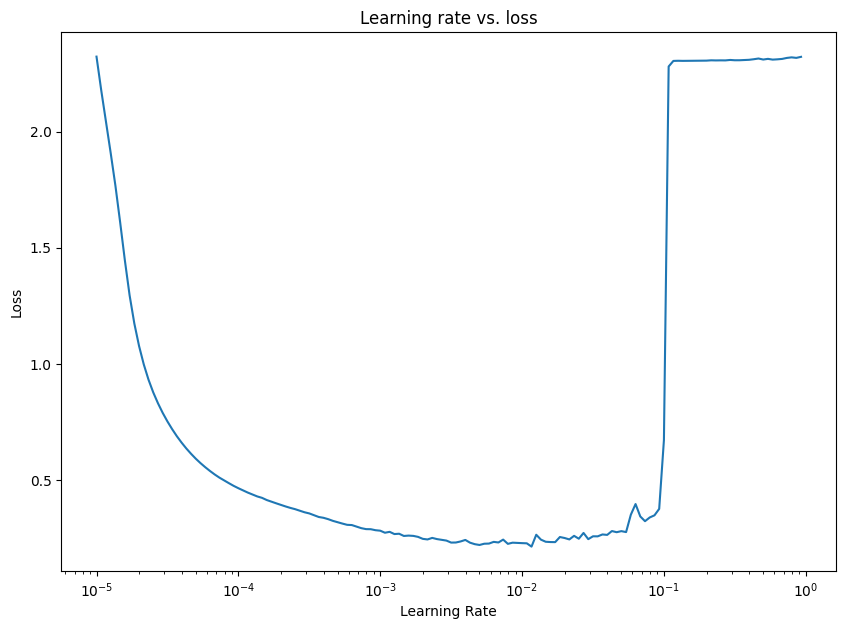

In [17]:
lrs = 1e-5 * (10 ** (np.arange(150)/30))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 0.0011``` is the safest option.

### **Create Model with Optimal Learning Rate**

#### **Model Trained on Raw Data**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])  
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0011),
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, 
                    epochs=30,
                    batch_size=128,
                    validation_data=(test_data, test_labels)
                    )

Epoch 1/30


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

24/59 [===========>..................] - ETA: 0s - loss: 35.7029 - accuracy: 0.3539 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


59/59 [==============================] - 2s 12ms/step - loss: 15.7854 - accuracy: 0.3398 - val_loss: 1.8520 - val_accuracy: 0.3731
Epoch 2/30
59/59 [==============================] - 0s 8ms/step - loss: 1.7732 - accuracy: 0.3872 - val_loss: 1.7328 - val_accuracy: 0.3971
Epoch 3/30
59/59 [==============================] - 0s 7ms/step - loss: 1.6665 - accuracy: 0.4095 - val_loss: 1.6431 - val_accuracy: 0.4184
Epoch 4/30
59/59 [==============================] - 1s 9ms/step - loss: 1.5935 - accuracy: 0.4256 - val_loss: 1.5843 - val_accuracy: 0.4369
Epoch 5/30
59/59 [==============================] - 0s 8ms/step - loss: 1.5080 - accuracy: 0.4541 - val_loss: 1.4803 - val_accuracy: 0.4713
Epoch 6/30
59/59 [==============================] - 1s 9ms/step - loss: 1.3590 - accuracy: 0.5117 - val_loss: 1.3313 - val_accuracy: 0.5329
Epoch 7/30
59/59 [==============================] - 1s 9ms/step - loss: 1.2681 - accuracy: 0.5378 - val_loss: 1.2813 - val_accuracy: 0.5505
Epoch 8/30
59/59 [===========

#### **Model Trained on Normalized Data**

In [ ]:
model_normalized = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])  

model_normalized.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=6.25e-4),
              metrics=['accuracy'])

history = model_normalized.fit(train_data_normalized, train_labels, 
                    epochs=30,
                    batch_size=128,
                    validation_data=(test_data_normalized, test_labels)
                    )

Epoch 1/30


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 7/59 [==>...........................] - ETA: 0s - loss: 1.9895 - accuracy: 0.3443  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


59/59 [==============================] - 2s 16ms/step - loss: 1.0382 - accuracy: 0.6593 - val_loss: 0.6476 - val_accuracy: 0.7783
Epoch 2/30
59/59 [==============================] - 1s 9ms/step - loss: 0.5561 - accuracy: 0.8127 - val_loss: 0.5266 - val_accuracy: 0.8155
Epoch 3/30
59/59 [==============================] - 1s 9ms/step - loss: 0.4809 - accuracy: 0.8364 - val_loss: 0.4857 - val_accuracy: 0.8315
Epoch 4/30
59/59 [==============================] - 1s 9ms/step - loss: 0.4455 - accuracy: 0.8464 - val_loss: 0.4596 - val_accuracy: 0.8377
Epoch 5/30
59/59 [==============================] - 1s 9ms/step - loss: 0.4187 - accuracy: 0.8572 - val_loss: 0.4406 - val_accuracy: 0.8465
Epoch 6/30
59/59 [==============================] - 0s 8ms/step - loss: 0.4029 - accuracy: 0.8600 - val_loss: 0.4246 - val_accuracy: 0.8511
Epoch 7/30
59/59 [==============================] - 0s 8ms/step - loss: 0.3891 - accuracy: 0.8645 - val_loss: 0.4159 - val_accuracy: 0.8537
Epoch 8/30
59/59 [============

### **Display Results**

In [53]:
import random

# Create a function for plotting a random image along with its prediction
def plot_random_image(model, images, true_labels, classes):
  """Picks a random image, plots it and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    images: a set of random images (in tensor form).
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.

  Returns:
    A plot of a random image from `images` with a predicted class label from `model`
    as well as the truth class label from `true_labels`.
  """
  # Setup random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28)) # have to reshape to get into right size for model
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color=color) # set the color to green or red

In [54]:

def plot_image(model, images, true_labels, classes, index):
  """Plots a single image and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    target: the index of the image to plot.
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.

  Returns:
    A plot of the image at index `target`.
  """
  
  # Select image and true label
  target_image = images[index]
  true_label = classes[true_labels[index]]

  # Predict on one image
  pred_probs = model.predict(tf.expand_dims(target_image, axis=0)) 
  pred_label = classes[pred_probs.argmax()]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel(
        f"Pred: {pred_label} {100 * tf.reduce_max(pred_probs):.2f}% | True: {true_label}",
        color=color
    ) # set the color to green or red

In [55]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)

#### **Accuracy / Loss Graph**

Text(0, 0.5, 'Loss')

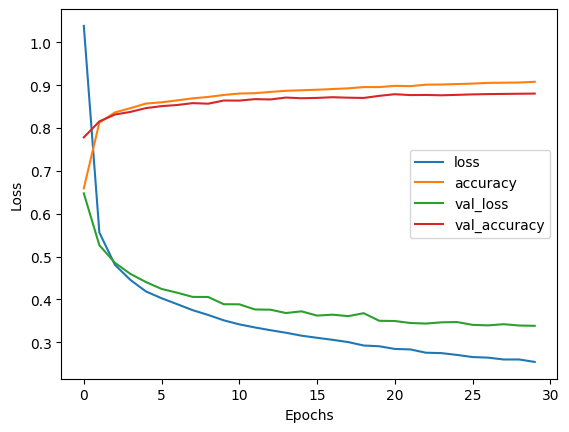

In [56]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')

#### **Normalized vs Raw Training Sets**

1/1 [==============================] - 0s 25ms/step


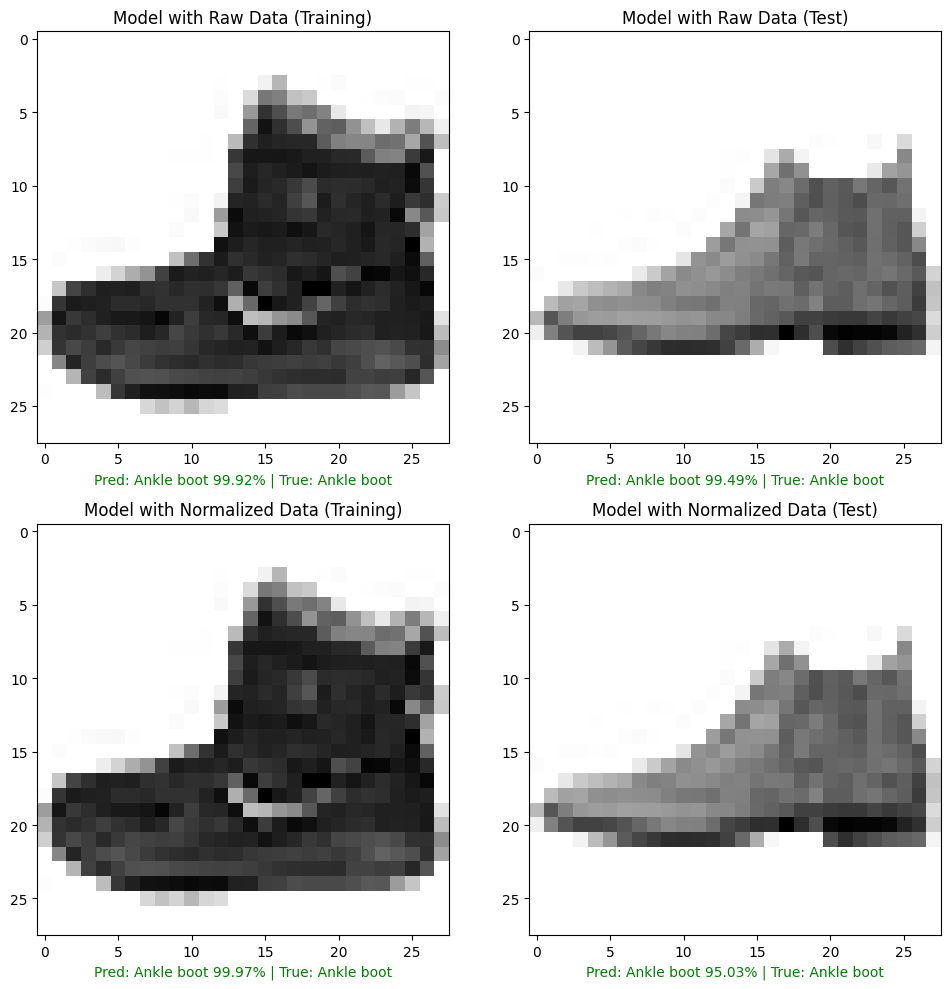

In [57]:
plt.figure(figsize=(10, 10))

plots = [
    ('Model with Raw Data (Training)', model, train_data, train_labels),
    ('Model with Raw Data (Test)', model, test_data, test_labels),
    ('Model with Normalized Data (Training)', model_normalized, train_data_normalized, train_labels),
    ('Model with Normalized Data (Test)', model_normalized, test_data_normalized, test_labels)
]

for i, (title, selected_model, img_data, labels) in enumerate(plots):
    plt.subplot(2, 2, i + 1)   # create/select subplot first
    plt.title(title)           # then set title on that subplot

    plot_image(
        selected_model,
        img_data,
        labels,
        class_names,
        0
    )

plt.tight_layout()


#### **Confusion Matrix**

In [58]:
y_probs = model.predict(test_data)
y_probs[0].argmax(), class_names[y_probs[0].argmax()]
y_preds = y_probs.argmax(axis=1)

313/313 [==============================] - 1s 3ms/step


In [59]:
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[500,   1,   3,  30, 438,   0,  19,   1,   8,   0],
       [  2, 945,   0,  27,  23,   0,   2,   0,   1,   0],
       [  2,   0,   0,   4, 988,   0,   5,   0,   1,   0],
       [  2,   7,   4, 781, 172,   1,  31,   0,   2,   0],
       [  0,   0,   0,  11, 971,   3,  13,   0,   2,   0],
       [  1,   0,   0,   0,   2, 925,   0,  47,   3,  22],
       [ 31,   0,   1,  22, 916,   0,  19,   0,  11,   0],
       [  0,   0,   0,   0,   1,  16,   0, 948,   0,  35],
       [  0,   1,   0,   4,  33,   1,  16,   4, 941,   0],
       [  0,   0,   0,   0,   3,   9,   0,  49,   0, 939]])

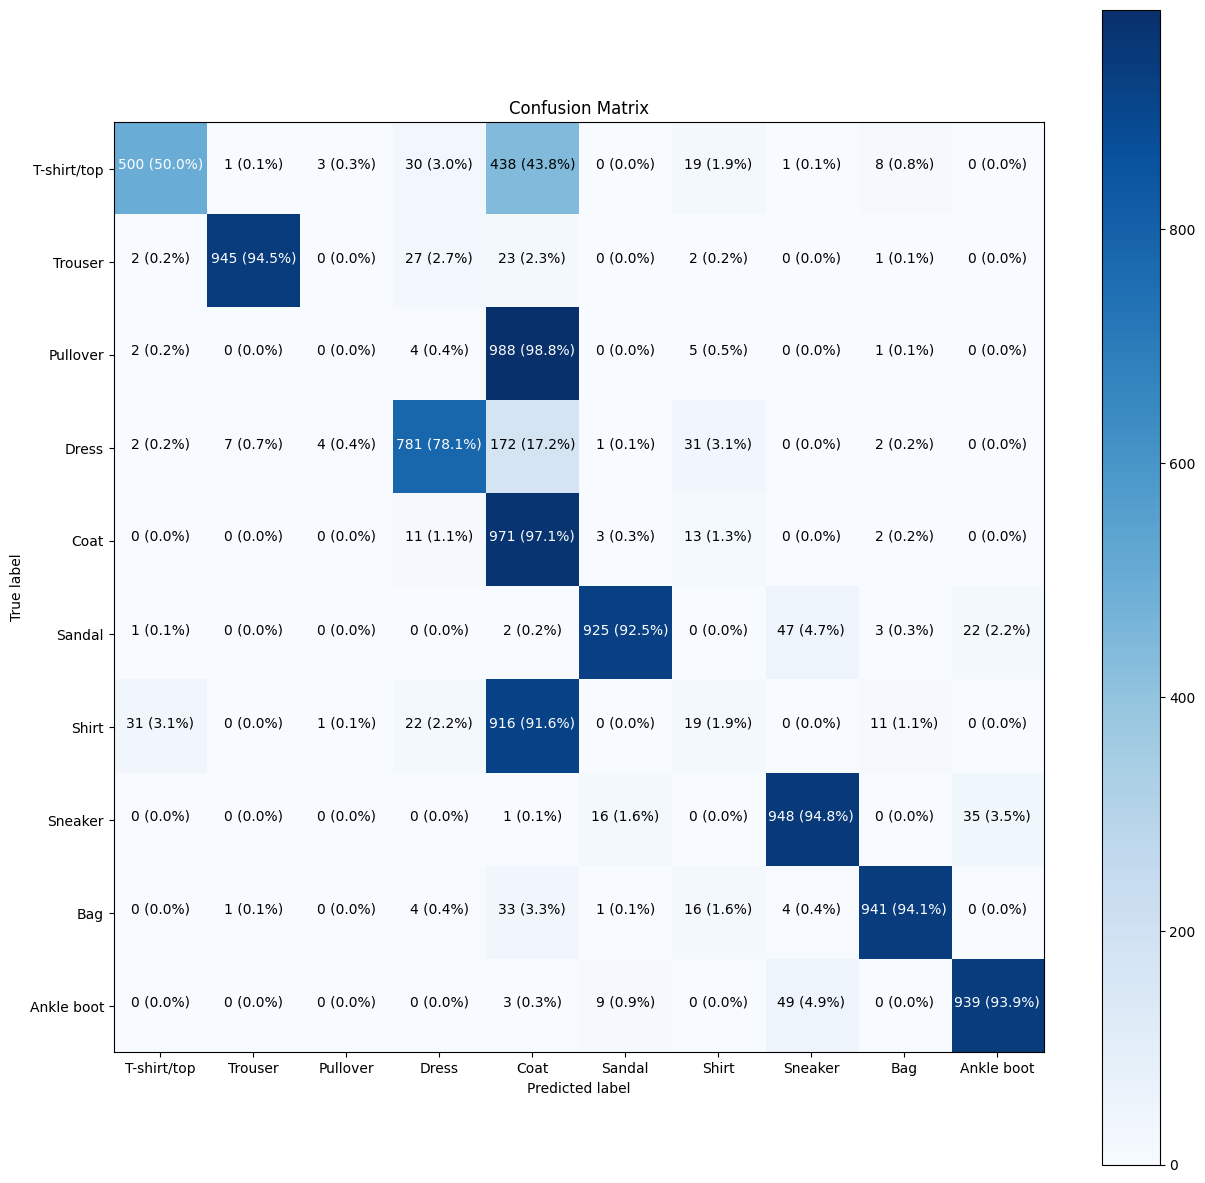

In [60]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10)

#### **Random Sample Predictions**

1/1 [==============================] - 0s 24ms/step


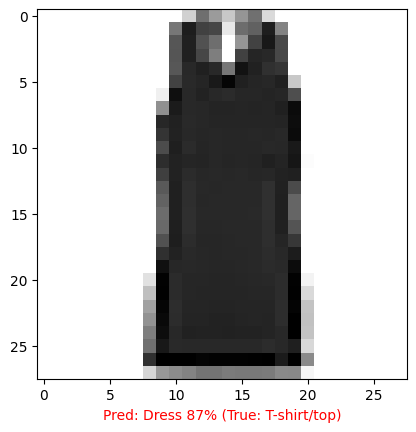

In [61]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 20ms/step


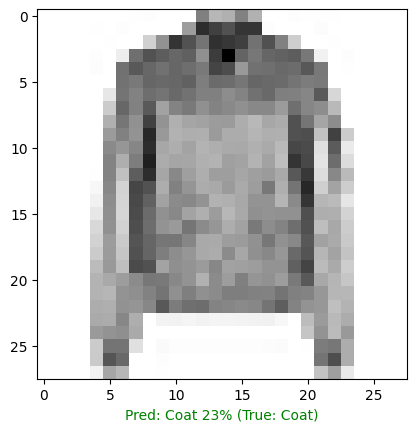

In [62]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 22ms/step


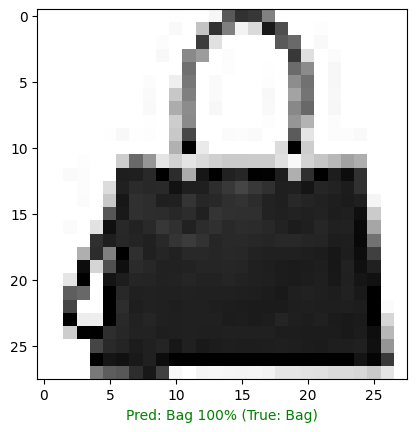

In [63]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 26ms/step


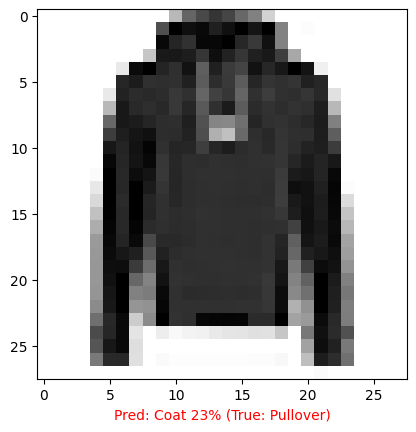

In [64]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 33ms/step


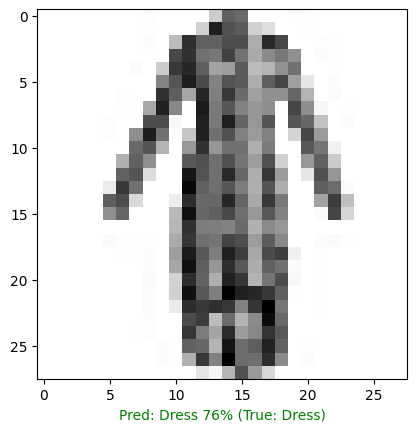

In [65]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)